In [2]:
import joblib
import pandas as pd

# Load all the trained models
print("Loading tranied models...")
rf_model = joblib.load('../models/rf_final.pkl')
xgb_model = joblib.load('../models/xgb_final.pkl')
lgbm_model = joblib.load('../models/lgbm_final.pkl')

# Load test sets
print("Loading test datasets...")
X_test_rf = pd.read_csv('../data/processed/X_test_rf.csv')
X_test_native = pd.read_pickle('../data/processed/X_test_native.pkl')

# Load target variable and convert to 1D
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("\nAll models and test datasets have been successfully loaded")
print(f"  Random Forest Test Set (X_test_rf): {X_test_rf.shape}")
print(f"  Native Boosters Test Set (X_test_native): {X_test_native.shape}")
print(f"  Target Labels (y_test): {y_test.shape}")



Loading tranied models...
Loading test datasets...

All models and test datasets have been successfully loaded
  Random Forest Test Set (X_test_rf): (726, 158)
  Native Boosters Test Set (X_test_native): (726, 30)
  Target Labels (y_test): (726,)


Generate predictions

Error due to XGBoost Category Alignment Issue fix in next cell 

In [3]:
# Random Forest prediction
rf_preds = rf_model.predict(X_test_rf)
rf_proba = rf_model.predict_proba(X_test_rf)[:, 1]

# XGBoost prediction
xgb_preds = xgb_model.predict(X_test_native)
xgb_proba = xgb_model.predict_proba(X_test_native)[:, 1]

# LightGBM prediction
lgbm_preds = lgbm_model.predict(X_test_native)
lgbm_proba = lgbm_model.predict_proba(X_test_native)[:, 1]

print("Prediction Arrays Successfully Generated:")
print(f"  Random Forest - Classes: {rf_preds.shape}, Probabilities: {rf_proba.shape}")
print(f"  XGBoost       - Classes: {xgb_preds.shape}, Probabilities: {xgb_proba.shape}")
print(f"  LightGBM      - Classes: {lgbm_preds.shape}, Probabilities: {lgbm_proba.shape}")

XGBoostError: [15:21:47] /Users/runner/work/xgboost/xgboost/src/data/cat_container.h:29: Found a category not in the training set for the 1th (0-based) column: `21`
Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x00000001232161ec dmlc::LogMessageFatal::~LogMessageFatal() + 124
  [bt] (1) 2   libxgboost.dylib                    0x00000001233943cc xgboost::EncErrorPolicy::Error(std::__1::basic_string<char, std::__1::char_traits<char>, std::__1::allocator<char>>&&) const + 88
  [bt] (2) 3   libxgboost.dylib                    0x0000000123403474 void enc::detail::ReportMissing<enc::Policy<xgboost::EncErrorPolicy>>(enc::Policy<xgboost::EncErrorPolicy> const&, std::__1::basic_string<char, std::__1::char_traits<char>, std::__1::allocator<char>> const&, unsigned long) + 168
  [bt] (3) 4   libxgboost.dylib                    0x0000000123405118 auto void enc::Recode<enc::Policy<xgboost::EncErrorPolicy>>(enc::Policy<xgboost::EncErrorPolicy> const&, enc::detail::ColumnsViewImpl<s

In [4]:
import pandas as pd

# Load the training data to retrieve the master categorical features
print("Loading X_train_native to align categorical features...")
X_train_native = pd.read_pickle('../data/processed/X_train_native.pkl')

# Loop through all categorical columns and align the test set categories
for col in X_test_native.select_dtypes(include=['category']).columns:
    # Extract the exact list of categories the model learned during training
    train_categories = X_train_native[col].cat.categories

    # Map the test set categories to the training set categories
    X_test_native[col] = pd.Categorical(X_test_native[col], categories=train_categories)

print("Categorical features aligned successfully\n")

print("Generating predictions...\n")

# Random Forest prediction
rf_preds = rf_model.predict(X_test_rf)
rf_proba = rf_model.predict_proba(X_test_rf)[:, 1]

# XGBoost prediction
xgb_preds = xgb_model.predict(X_test_native)
xgb_proba = xgb_model.predict_proba(X_test_native)[:, 1]

# LightGBM prediction
lgbm_preds = lgbm_model.predict(X_test_native)
lgbm_proba = lgbm_model.predict_proba(X_test_native)[:, 1]

print("Prediction Arrays Successfully Generated:")
print(f"  Random Forest - Classes: {rf_preds.shape}, Probabilities: {rf_proba.shape}")
print(f"  XGBoost       - Classes: {xgb_preds.shape}, Probabilities: {xgb_proba.shape}")
print(f"  LightGBM      - Classes: {lgbm_preds.shape}, Probabilities: {lgbm_proba.shape}")

Loading X_train_native to align categorical features...
Categorical features aligned successfully

Generating predictions...

Prediction Arrays Successfully Generated:
  Random Forest - Classes: (726,), Probabilities: (726,)
  XGBoost       - Classes: (726,), Probabilities: (726,)
  LightGBM      - Classes: (726,), Probabilities: (726,)


/var/folders/wm/y1qvdc9j1jl9sqv3jtbt7dvw0000gn/T/ipykernel_44473/2531545662.py:13: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_test_native[col] = pd.Categorical(X_test_native[col], categories=train_categories)


In [ ]:
# How many students have unseen categories?
categorical_cols = [
    'Marital status',
    'Nacionality',
    "Mother's occupation",
    "Father's occupation",
    'Application mode',
    'Course',
    'Previous qualification'
]
for col in categorical_cols:
    unseen = ~X_test_native[col].isin(X_train_native[col].cat.categories)
    if unseen.sum() > 0:
        print(f"{col}: {unseen.sum()} unseen values")

Nacionality: 1 unseen values
Father's occupation: 3 unseen values
Application mode: 1 unseen values
Previous qualification: 1 unseen values


Evaluation Metrics

In [9]:
import pandas as pd
from sklearn.metrics import(
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# Define a helper function to calculate all metrics for a single model
def get_evaluation_metrics(y_true, y_pred, y_proba, model_name):
    # Calculate standard metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1)
    rec = recall_score(y_true, y_pred, pos_label=1)

    # Calculate F1 variants
    f1_dropout = f1_score(y_true, y_pred, pos_label=1)
    f1_macro = f1_score(y_true, y_pred, average='macro')

    # Calculate AUROC
    auc = roc_auc_score(y_true, y_proba)

    # Generate Confusion Matrix and flatten it to (TN, FP, FN, FP)
    cm = confusion_matrix(y_true, y_pred).ravel()

    # Retrun as a dictionary for easy DataFrame construction
    return {
        'Model': model_name,
        'F1 Score (Dropout)': f1_dropout,
        'AUROC': auc,
        'Accuracy': acc,
        'Precision (Dropout)': prec,
        'Recall (Dropout)': rec,
        'F1 Score (Macro Avg)': f1_macro,
        'Confusion Matrix (TN, FP, FN, TP)': cm
    }

# Extract metrics for all three models
metrics_rf = get_evaluation_metrics(y_test, rf_preds, rf_proba, 'Random Forest')
metrics_xgb = get_evaluation_metrics(y_test, xgb_preds, xgb_proba, 'XGBoost')
metrics_lgbm = get_evaluation_metrics(y_test, lgbm_preds, lgbm_proba, 'LightGBM')

# Combine into a pandas DataFrame for a clean layout
df_metrics = pd.DataFrame([metrics_rf, metrics_xgb, metrics_lgbm])
df_metrics.set_index('Model', inplace=True)

# Round numerical columns to 4 decimal places
float_cols = df_metrics.select_dtypes(include=['float64']).columns
df_metrics[float_cols] = df_metrics[float_cols].round(4)

# Display the table and save it
display(df_metrics)
df_metrics.to_csv('../outputs/final_model_metrics_comparison.csv')
print("\nMetrics calculated and saved to outputs folder.")

,F1 Score (Dropout),AUROC,Accuracy,Precision (Dropout),Recall (Dropout),F1 Score (Macro Avg),"Confusion Matrix (TN, FP, FN, TP)"
Model,,,,,,,
Random Forest,0.8506,0.9482,0.8829,0.8491,0.8521,0.8772,"[399, 43, 42, 242]"
XGBoost,0.8715,0.9576,0.8981,0.8596,0.8838,0.8935,"[401, 41, 33, 251]"
LightGBM,0.8621,0.9552,0.8898,0.8446,0.8803,0.8852,"[396, 46, 34, 250]"



Metrics calculated and saved to outputs folder.


Confusion Matrices

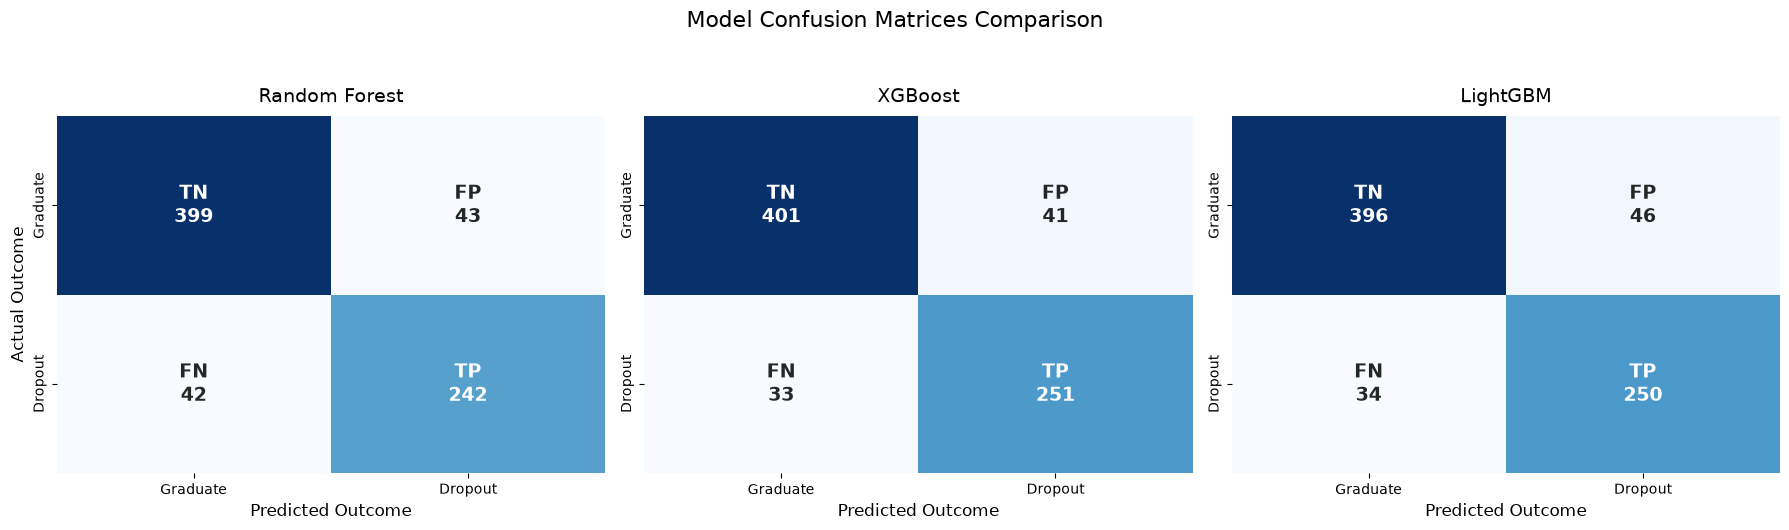

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Initialise a single figure with 3 columns for side by side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Group models and their predictions
model_data = [
    ('Random Forest', rf_preds),
    ('XGBoost', xgb_preds),
    ('LightGBM', lgbm_preds),
]
# Loop through the data and plot each matrix on its axis
for ax, (model_name, preds) in zip(axes, model_data):
    # Generate heatmap
    cm = confusion_matrix(
        y_test,
        preds,
    )
    # Create custom text labels for TN, FP, FN, TP along with the counts
    group_names = ['TN\n', 'FP\n', 'FN\n', 'TP\n']
    group_counts = [f"{value}" for value in cm.flatten()]

    # Zip them together and reshape into 2x2 grid
    labels = [f"{v1}{v2}" for v1, v2 in zip(group_names, group_counts)]
    labels = np.asarray(labels).reshape(2, 2)

    # Plot using seaborn
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Graduate', 'Dropout'], 
                yticklabels=['Graduate', 'Dropout'],
                annot_kws={"size": 14, "weight": "bold"})
    
    # Format each individual subplot
    ax.set_title(f'{model_name}', fontsize=14, pad=10)
    ax.set_xlabel('Predicted Outcome', fontsize=12)
    
    # Only show the Y axis label which is actual outcome on the far left plot
    if ax != axes[0]:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Actual Outcome', fontsize=12)

# Add Titles
plt.suptitle('Model Confusion Matrices Comparison', fontsize=16, y=1.05)
plt.tight_layout()

plt.savefig('../outputs/figures/confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


ROC Curve

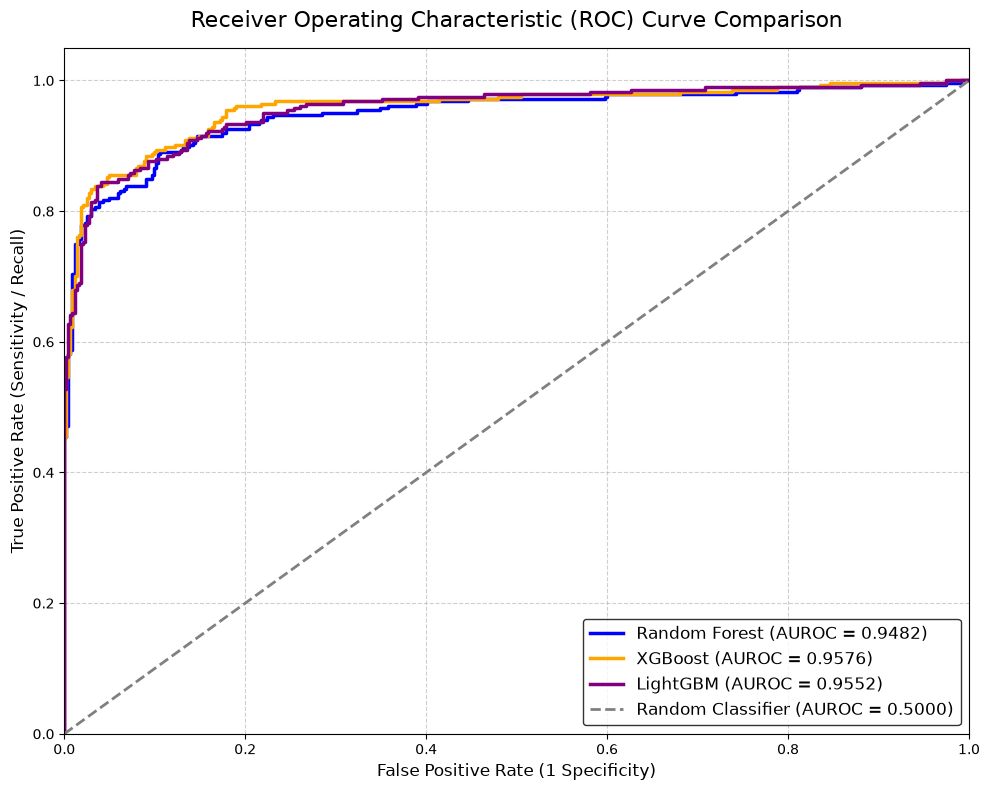

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Plot figure size
plt.figure(figsize=(10, 8))

# Group the models
model_proba_data = [
    ('Random Forest', rf_proba, 'blue'),
    ('XGBoost', xgb_proba, 'orange'),
    ('LightGBM', lgbm_proba, 'purple')
]
# Loop through
for model_name, proba, color in model_proba_data:
    # Calculate false positive rate X axis and true positive rate Y axis
    fpr, tpr, threshold = roc_curve(y_test, proba)
    # Calculate the exact Area under the curve (AUROC)
    roc_auc = auc(fpr, tpr)

    # Plot the model's line and embed the score directly into the legend
    plt.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{model_name} (AUROC = {roc_auc:.4f})')

# Plot the baseline diagonal line which is Random Classifier
plt.plot([0, 1], [0, 1], color='gray', linewidth=2, linestyle='--', 
         label='Random Classifier (AUROC = 0.5000)')

# Apply titles
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=16, pad=15)
plt.xlabel('False Positive Rate (1 Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.legend(loc='lower right', fontsize=12, frameon=True, edgecolor='black')
plt.grid(True, linestyle='--', alpha=0.6)

# Force the axes to strictly start and end at 0 and 1
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()

plt.savefig('../outputs/figures/roc_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

F1 Score Benchmark Comparison

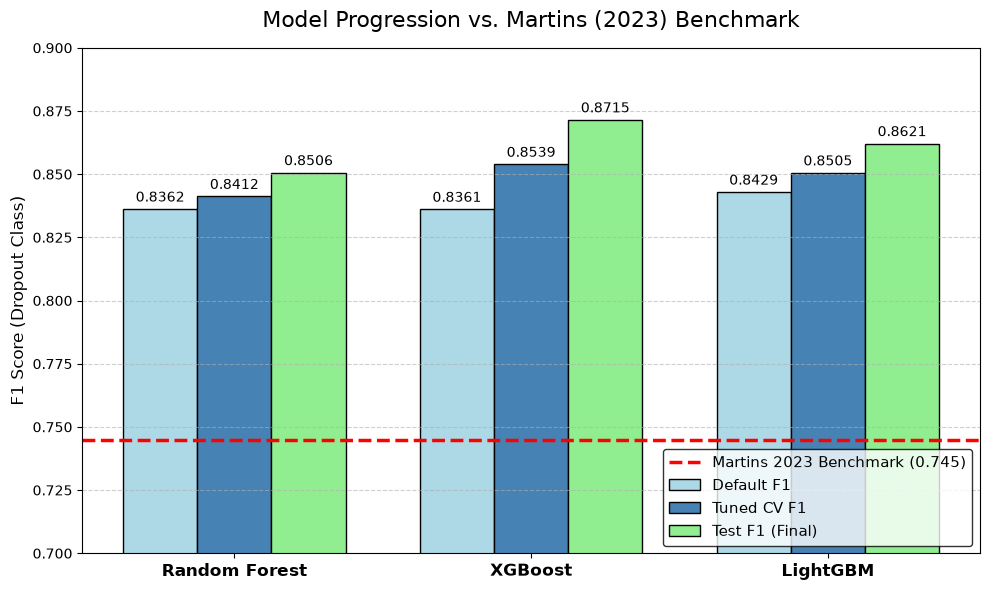

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Define the models
models = ['Random Forest', 'XGBoost', 'LightGBM']

# F1 scores

default_f1 = [0.8362, 0.8361, 0.8429]
tuned_cv_f1 = [0.8412, 0.8539, 0.8505]
test_f1 = [0.8506, 0.8715, 0.8621]

# Set up numerical positions on the x axis
x = np.arange(len(models)) # creates an array
width = 0.25 # exact with of each individual bar

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the three sets of bar side by side
bars1 = ax.bar(x - width, default_f1, width, label='Default F1', color='lightblue', edgecolor='black')
bars2 = ax.bar(x, tuned_cv_f1, width, label='Tuned CV F1', color='steelblue', edgecolor='black')
bars3 = ax.bar(x + width, test_f1, width, label='Test F1 (Final)', color='lightgreen', edgecolor='black')

# Add numerical labels on top of the bars
ax.bar_label(bars1, fmt='%.4f', padding=3, fontsize=10)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=10)
ax.bar_label(bars3, fmt='%.4f', padding=3, fontsize=10)
# Add the benchmark score which we beating
ax.axhline(y=0.745, color='red', linestyle='--', linewidth=2.5,
           label='Martins 2023 Benchmark (0.745)')

# Apply titles
ax.set_ylabel('F1 Score (Dropout Class)', fontsize=12)
ax.set_title('Model Progression vs. Martins (2023) Benchmark', fontsize=16, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12, fontweight='bold')
ax.set_ylim([0.70, 0.90]) # Lock Y axis from 0 to 1 to properly represent percentages

# Format the legend and grid
ax.legend(loc='lower right', fontsize=11, frameon=True, edgecolor='black')
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../outputs/figures/f1_benchmark_comparison.png', dpi=300, bbox_inches='tight')
plt.show()